<a href="https://colab.research.google.com/github/mishraaashkacs242511-maker/Aashka/blob/main/T095_Aashka_Mishra_AI_Prac_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving BankNote_Authentication.csv to BankNote_Authentication (1).csv
First 5 rows:
   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

Dataset Shape:
(1372, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB
None

Missing Values:
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

Class Distribution:
class
0    762
1    610


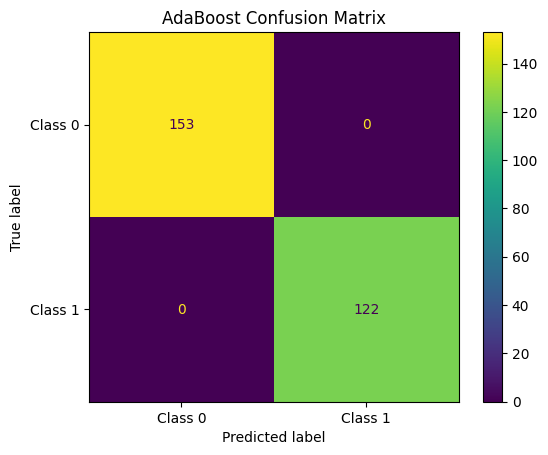


Actual vs Predicted:
    Actual  Weak Classifier  AdaBoost
0        0                0         0
1        1                1         1
2        0                1         0
3        1                1         1
4        1                1         1
5        1                0         1
6        0                0         0
7        0                0         0
8        0                1         0
9        1                1         1
10       0                0         0
11       1                1         1
12       0                0         0
13       0                0         0
14       0                0         0
15       0                0         0
16       1                1         1
17       1                1         1
18       1                1         1
19       0                1         0
PERFORMANCE COMPARISON
Weak Decision Tree Accuracy: 82.91 %
AdaBoost Accuracy: 100.0 %
Improvement: 17.09 percentage points


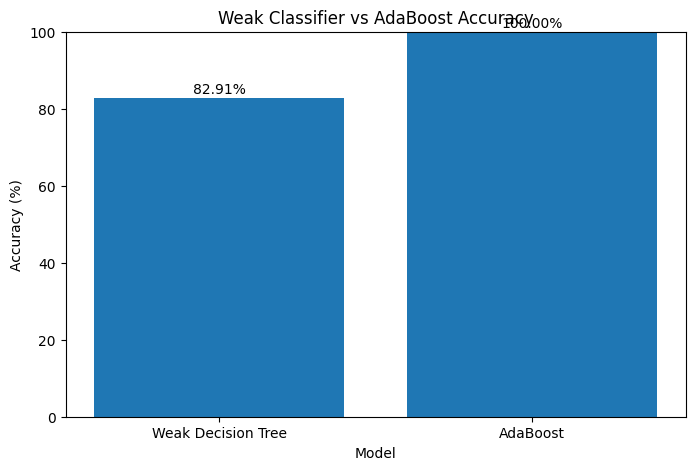

ADABOOST PARAMETER OPTIMIZATION
Best Parameters:
{'learning_rate': 1.0, 'n_estimators': 100}

Best Cross-Validation Accuracy:
99.82 %
OPTIMIZED ADABOOST RESULTS
Optimized AdaBoost Accuracy: 100.0 %

Optimized AdaBoost Classification Report:
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00       153
     Class 1       1.00      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275


Optimized Confusion Matrix:
[[153   0]
 [  0 122]]


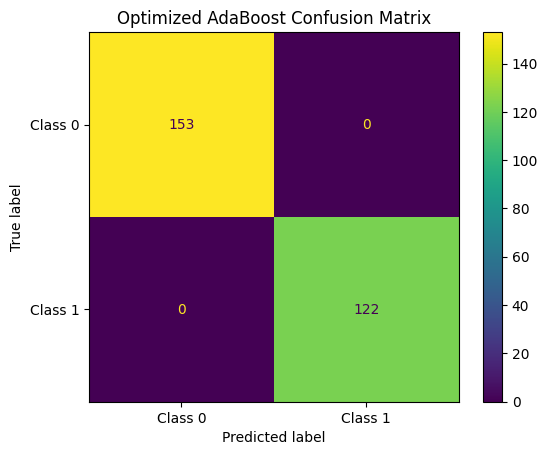


Feature Importance:
variance    0.348978
skewness    0.331345
curtosis    0.290776
entropy     0.028901
dtype: float64


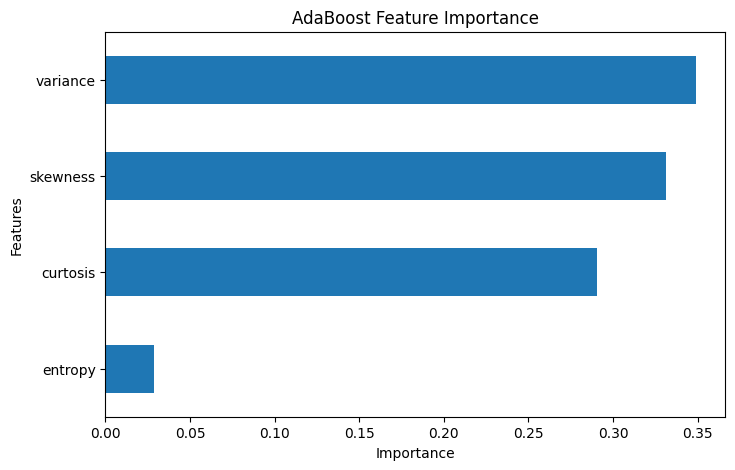

FINAL MODEL COMPARISON
Weak Decision Tree: 82.91%
Basic AdaBoost: 100.00%
Optimized AdaBoost: 100.00%
NEW BANKNOTE PREDICTION
Prediction: Class 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

uploaded = files.upload()

df = pd.read_csv("BankNote_Authentication.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df['class'].value_counts())

X = df[['variance', 'skewness', 'curtosis', 'entropy']]

y = df['class']

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

weak_classifier = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

weak_classifier.fit(X_train, y_train)

y_pred_weak = weak_classifier.predict(X_test)

weak_accuracy = accuracy_score(
    y_test,
    y_pred_weak
)

print("WEAK CLASSIFIER RESULTS")


print("Classifier: Decision Tree")
print("Maximum Depth: 1")

print(
    "Accuracy:",
    round(weak_accuracy * 100, 2),
    "%"
)

ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1,
        random_state=42
    ),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

ada_model.fit(X_train, y_train)

print("\nAdaBoost model trained successfully!")

y_pred_ada = ada_model.predict(X_test)

print("\nAdaBoost Predictions:")
print(y_pred_ada)

ada_accuracy = accuracy_score(
    y_test,
    y_pred_ada
)

print(
    "AdaBoost Accuracy:",
    round(ada_accuracy * 100, 2),
    "%"
)

print("\nAdaBoost Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_ada,
        target_names=[
            "Class 0",
            "Class 1"
        ]
    )
)

cm = confusion_matrix(
    y_test,
    y_pred_ada
)

print("\nAdaBoost Confusion Matrix:")
print(cm)


# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Class 0",
        "Class 1"
    ]
)

disp.plot()

plt.title("AdaBoost Confusion Matrix")

plt.show()

results = pd.DataFrame({
    'Actual': y_test.values,
    'Weak Classifier': y_pred_weak,
    'AdaBoost': y_pred_ada
})

print("\nActual vs Predicted:")
print(results.head(20))

print("PERFORMANCE COMPARISON")

print(
    "Weak Decision Tree Accuracy:",
    round(weak_accuracy * 100, 2),
    "%"
)

print(
    "AdaBoost Accuracy:",
    round(ada_accuracy * 100, 2),
    "%"
)

improvement = (
    ada_accuracy - weak_accuracy
) * 100

print(
    "Improvement:",
    round(improvement, 2),
    "percentage points"
)

models = [
    "Weak Decision Tree",
    "AdaBoost"
]

accuracies = [
    weak_accuracy * 100,
    ada_accuracy * 100
]

plt.figure(figsize=(8, 5))

plt.bar(
    models,
    accuracies
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")

plt.title(
    "Weak Classifier vs AdaBoost Accuracy"
)

plt.ylim(0, 100)

for i, value in enumerate(accuracies):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha='center'
    )

plt.show()

print("ADABOOST PARAMETER OPTIMIZATION")


param_grid = {
    'n_estimators': [25, 50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}


grid_search = GridSearchCV(
    AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=1,
            random_state=42
        ),
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)


grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")

print(
    round(
        grid_search.best_score_ * 100,
        2
    ),
    "%"
)

best_ada = grid_search.best_estimator_

y_pred_best = best_ada.predict(X_test)

best_accuracy = accuracy_score(
    y_test,
    y_pred_best
)
print("OPTIMIZED ADABOOST RESULTS")

print(
    "Optimized AdaBoost Accuracy:",
    round(best_accuracy * 100, 2),
    "%"
)

print("\nOptimized AdaBoost Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=[
            "Class 0",
            "Class 1"
        ]
    )
)

cm_best = confusion_matrix(
    y_test,
    y_pred_best
)

print("\nOptimized Confusion Matrix:")
print(cm_best)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best,
    display_labels=[
        "Class 0",
        "Class 1"
    ]
)

disp.plot()

plt.title(
    "Optimized AdaBoost Confusion Matrix"
)

plt.show()

feature_importance = pd.Series(
    best_ada.feature_importances_,
    index=X.columns
)

print("\nFeature Importance:")
print(feature_importance)

plt.figure(figsize=(8, 5))

feature_importance.sort_values().plot(
    kind='barh'
)

plt.xlabel("Importance")
plt.ylabel("Features")

plt.title(
    "AdaBoost Feature Importance"
)

plt.show()

print("FINAL MODEL COMPARISON")

print(
    f"Weak Decision Tree: "
    f"{weak_accuracy * 100:.2f}%"
)

print(
    f"Basic AdaBoost: "
    f"{ada_accuracy * 100:.2f}%"
)

print(
    f"Optimized AdaBoost: "
    f"{best_accuracy * 100:.2f}%"
)

new_banknote = [[
    2.0,
    3.0,
    1.0,
    0.5
]]

new_prediction = best_ada.predict(
    new_banknote
)

print("NEW BANKNOTE PREDICTION")

if new_prediction[0] == 0:
    print("Prediction: Class 0")
else:
    print("Prediction: Class 1")